<center><h1>Zhan_Jenna_HW2</h1></center>
<br>
<br>

Name:Jenna Zhan 
<br>
Github Username:jenna-zhan 
<br>
USC ID: 2477604908

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsRegressor

Get the Cycle Power Plant Data Set

In [2]:
ccpp = pd.read_excel("../data/Folds5x2_pp.xlsx",sheet_name = 0)

### (b) Exploring the data

#### i. rows and columns

In [3]:
ccpp.shape

(9568, 5)

There are 9568 rows and 5 columns in the data set.The rows represent 9568 different hourly averaged observations collected from a combined cycle power plant operating at full load over a period of 6 years.The columns represent the independent variables Temperature (AT), Ambient Pressure (AP),
Relative Humidity (RH) and Exhaust Vacuum (V),and the dependent variable the net hourly electrical energy output (PE).

#### ii. pairwise scatterplots of all the variables

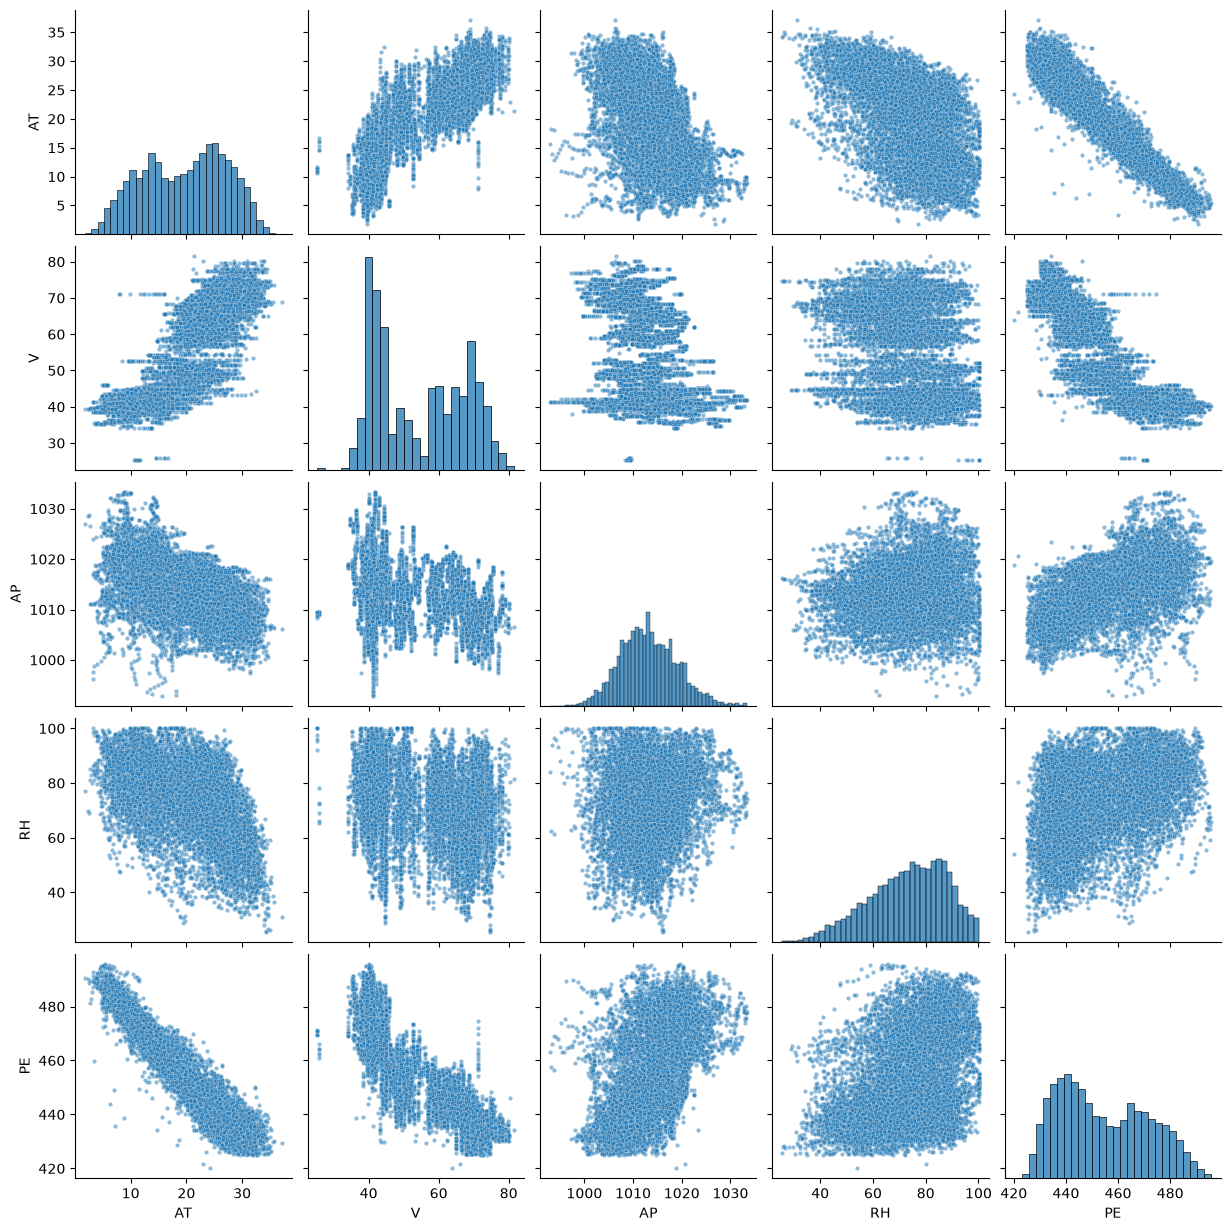

In [4]:
sns.pairplot(
    ccpp,
    plot_kws={"alpha" : 0.5,"s" : 10}
)
plt.show()

PE has a clear negative association with AT. PE also has a negative association with V but the association doesn't appear to be as strong as the association between PE and AT. The associations of PE with AP and RH appear to be positive but relatively week.
Among the predictors, AT and V have a positive association. AT also has a negative association with AP and a weak negative association with RH.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
ccpp_summary = pd.DataFrame({
    "mean" : ccpp.mean(),
    "median" : ccpp.median(),
    "range" : ccpp.max() - ccpp.min(),
    "first quartile" : ccpp.quantile(0.25),
    "third quartile" : ccpp.quantile(0.75),
    "interquartile range" : ccpp.quantile(0.75) - ccpp.quantile(0.25)
})

ccpp_summary.round(2)

,mean,median,range,first quartile,third quartile,interquartile range
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple Linear Regression

In [6]:
model_at = smf.ols("PE ~ AT", data = ccpp).fit()
print(model_at.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:57:59   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.0

In [7]:
model_v = smf.ols("PE ~ V", data = ccpp).fit()
print(model_v.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:57:59   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    517.8015      0.378   1370.218      0.0

In [8]:
model_ap = smf.ols("PE ~ AP", data = ccpp).fit()
print(model_ap.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:57:59   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1055.2610     25.459    -41.449      0.0

In [9]:
model_rh = smf.ols("PE ~ RH", data = ccpp).fit()
print(model_rh.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:57:59   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    420.9618      0.823    511.676      0.0

All these 4 predictors have statistically significant associations with PE because their p-values are less than 0.001.In addition,the AT model and the V model have relatively larger R-squared values so they have stronger individual linear association with PE. While the AP model and the RH model have smaller R-squared value which means they have weaker individual linear association with PE.

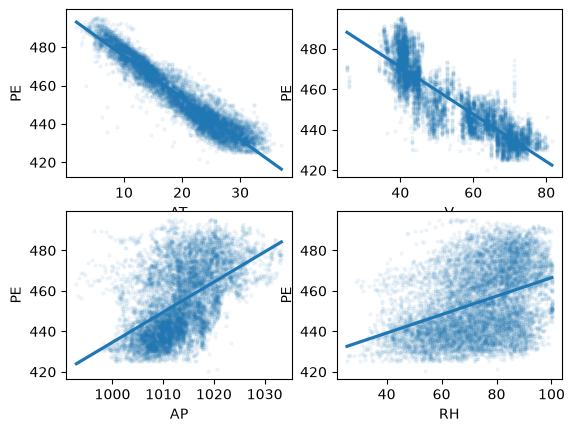

In [10]:
predictors = ["AT" , "V" , "AP" , "RH" ]

fig , axes = plt.subplots(2,2)

for predictor , ax in zip(predictors, axes.flatten()) :
    sns.regplot(
        data = ccpp,
        x = predictor,
        y = "PE",
        ax = ax,
        scatter_kws = {"alpha" : 0.05,"s" : 5}
    )

plt.show()

The regression plots support the previous assertions. AT and V have negative associations with PE, and AP and RH have positive associations with PE. The observations are most closely concentrated around the fitted line in the AT model, which is consistent with its highest R-squared value. The observations in the V plot are also relatively concentrated around the fitted regression line, which is consistent with its relatively high R-squared value. The AP and RH plots show considerably more dispersion around the fitted lines, which is consistent with their relatively lower R-squared values.

There are outliers in each of the plots.Each plot contains a few observations that lie relatively far from the fitted regression line.

### (d) Multiple Regression

In [11]:
model_d = smf.ols("PE ~ AT + V + AP + RH", data = ccpp).fit()
print(model_d.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:58:01   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

Holding the other predictors constant, AT, V, and RH have negative associations with PE, and AP has a positive association with PE. In particular, the coefficient of RH changes from positive in the individual linear regression to negative in the multiple regression.

Both the R-squared and adjusted R-squared values are 0.929, indicating that the model fits the data relatively well. All four predictors have p-values below 0.001, and their 95% confidence intervals do not contain zero. Therefore, the null hypothesis can be rejected for all four predictors.

### (e) 1c Compare to 1d

In [12]:
model_uni = [model_at, model_v , model_ap , model_rh]
coef = pd.DataFrame({
    "predictor" : predictors,
    "univariate regression" : [
        model.params[predictor]
        for model , predictor in zip(model_uni , predictors)
    ] , 
    "multiple regression" : [
        model_d.params[predictor]
        for predictor in predictors
    ]
})

coef.round(4)

,predictor,univariate regression,multiple regression
0,AT,-2.1713,-1.9775
1,V,-1.1681,-0.2339
2,AP,1.4899,0.0621
3,RH,0.4557,-0.1581


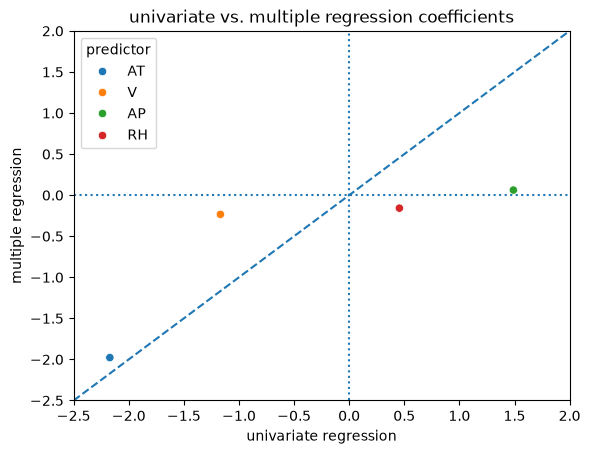

In [13]:
sns.scatterplot(
    data = coef,
    x = "univariate regression",
    y = "multiple regression",
    hue = "predictor"
)

plt.xlim(-2.5, 2)
plt.ylim(-2.5, 2)
plt.plot([-2.5, 2], [-2.5, 2], "--")
plt.axhline(y=0, linestyle=":")
plt.axvline(x=0, linestyle=":")
plt.title("univariate vs. multiple regression coefficients")
plt.show()

All four predictors are statistically significant in both the univariate and multiple regression models. However, their estimated coefficients change after the other predictors are included in the model.

The coefficient of AT is closest to the y = x reference line, indicating that it changes the least between the univariate and multiple regression models. The coefficient of RH also changes relatively small, but its sign changes from positive to negative, which means that its estimated association with PE changes from positive in the univariate regression model to negative in the multiple regression model. In contrast, the coefficients of V and AP are farther from the y = x reference line, indicating relatively larger changes. The signs of the coefficients for AT, V, and AP remain unchanged from the univariate regression models to the multiple regression model.

### (f) Nonlinear Association

In [14]:
model_at_nl = smf.ols(
    "PE ~ AT + I(AT ** 2) + I(AT ** 3)",
    data = ccpp
).fit()

print(model_at_nl.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:58:01   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      0.0

In [15]:
model_v_nl = smf.ols(
    "PE ~ V + I(V ** 2) + I(V ** 3)",
    data = ccpp
).fit()

print(model_v_nl.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:58:01   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    554.1468      9.151     60.557      0.0

In [16]:
ccpp_ap = ccpp.copy()
ccpp_ap["AP_centered"] = ccpp_ap["AP"] - ccpp_ap["AP"].mean()

model_ap_nl = smf.ols(
    "PE ~ AP_centered + I(AP_centered ** 2) + I(AP_centered ** 3)",
    data = ccpp_ap
).fit()

print(model_ap_nl.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     1350.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:58:01   Log-Likelihood:                -39032.
No. Observations:                9568   AIC:                         7.807e+04
Df Residuals:                    9564   BIC:                         7.810e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             453.0823    

In [17]:
model_rh_nl = smf.ols(
    "PE ~ RH + I(RH ** 2) + I(RH ** 3)",
    data = ccpp
).fit()

print(model_rh_nl.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:58:01   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    468.4135     10.545     44.422      0.0

There is evidence of nonlinear associations between each predictor and PE.

For AT, both the quadratic and cubic terms are statistically significant (p < 0.001), and the R-squared value increases from 0.899 to 0.912.

For V, the quadratic term is not significant (p = 0.768), but the cubic term is significant (p = 0.014). The R-squared value increases from 0.757 to 0.775.

For AP, the polynomial model fitted using the original, uncentered values had a model degree of freedom of 2 instead of the expected 3, indicating numerical instability. Therefore, AP was centered by subtracting its mean before fitting the cubic polynomial regression model. In the model, both the quadratic and cubic terms are statistically significant (p < 0.001). The R-squared value increases from 0.269 to 0.298.

For RH, both the quadratic and cubic terms are statistically significant (p < 0.001). However, the R-squared value increases only slightly from 0.152 to 0.154, suggesting that the practical improvement is small despite the statistical significance.

### (g) Interactions of Predictors

In [18]:
model_g = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2",
    data = ccpp
).fit()

print(model_g.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:58:01   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

At the 0.05 significance level, the interaction terms AT:V, AT:RH, V:AP, and AP:RH are statistically significant. In contrast, AT:AP and V:RH are not statistically significant. These results provide evidence that some predictors interact in their associations with PE.

### (h) Improvement

In [19]:
train_data, test_data = train_test_split(
    ccpp,
    test_size = 0.3,
    random_state = 123
)

print("shape of train data:",train_data.shape)
print("shape of test data:",test_data.shape)

x_train = train_data[predictors]
x_test = test_data[predictors]

y_train = train_data["PE"]
y_test = test_data["PE"]

x_train_centered = x_train - x_train.mean()
x_test_centered = x_test - x_train.mean()

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

x_train_poly = poly.fit_transform(x_train_centered)
x_test_poly = poly.transform(x_test_centered)

print("shape of train data involved all terms:",x_train_poly.shape)
print("shape of test data involved all terms:",x_test_poly.shape)

shape of train data: (6697, 5)
shape of test data: (2871, 5)
shape of train data involved all terms: (6697, 14)
shape of test data involved all terms: (2871, 14)


In [20]:
model_simple_train = smf.ols(
    "PE ~ AT + V + AP + RH",
    data = train_data
).fit()

print(model_simple_train.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                 2.258e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:58:01   Log-Likelihood:                -19529.
No. Observations:                6697   AIC:                         3.907e+04
Df Residuals:                    6692   BIC:                         3.910e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    469.2501     11.336     41.394      0.0

In [21]:
predictors_all = poly.get_feature_names_out(predictors)
predictors_all

x_train_poly = pd.DataFrame(
    x_train_poly,
    columns = predictors_all,
    index = x_train.index
)

x_test_poly = pd.DataFrame(
    x_test_poly,
    columns = predictors_all,
    index = x_test.index
)

x_train_poly_const = sm.add_constant(x_train_poly)

model_all_train = sm.OLS(
    y_train,
    x_train_poly_const,
).fit()

print(model_all_train.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     7508.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:58:01   Log-Likelihood:                -19049.
No. Observations:                6697   AIC:                         3.813e+04
Df Residuals:                    6682   BIC:                         3.823e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        453.2197      0.114   3959.738      0.0

From the summary of the full regression model containing all variables, the terms AT:AP, V^2, and V:RH are statistically insignificant because their p-values are greater than 0.05. Therefore, these three terms are removed from the full model.

In [22]:
x_train_selected = x_train_poly.drop(
    columns=["AT AP", "V^2", "V RH"]
)

x_train_selected = sm.add_constant(x_train_selected)

model_selected = sm.OLS(
    y_train,
    x_train_selected
).fit()

print(model_selected.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     9555.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:58:01   Log-Likelihood:                -19051.
No. Observations:                6697   AIC:                         3.813e+04
Df Residuals:                    6685   BIC:                         3.821e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        453.1181      0.098   4642.849      0.0

In [23]:
y_simple_train_pred = model_simple_train.predict(x_train)
y_simple_test_pred = model_simple_train.predict(x_test)

mse_simple_train = mean_squared_error(
    y_train,
    y_simple_train_pred
)
mse_simple_test = mean_squared_error(
    y_test,
    y_simple_test_pred
)

print("simple model train MSE:",mse_simple_train)
print("simple model test MSE:",mse_simple_test)

simple model train MSE: 19.969376443975687
simple model test MSE: 22.658769778031022


In [24]:
x_test_selected = x_test_poly.drop(
    columns=["AT AP", "V^2", "V RH"]
)

x_test_selected = sm.add_constant(x_test_selected)

print(x_train_selected.shape)
print(y_train.shape)

print(x_test_selected.shape)
print(y_test.shape)

(6697, 12)
(6697,)
(2871, 12)
(2871,)


In [25]:
y_all_train_pred = model_selected.predict(x_train_selected)
y_all_test_pred = model_selected.predict(x_test_selected)

mse_all_train = mean_squared_error(
    y_train,
    y_all_train_pred
)
mse_all_test = mean_squared_error(
    y_test,
    y_all_test_pred
)

print("selected model train MSE:",mse_all_train)
print("selected model test MSE:",mse_all_test)

selected model train MSE: 17.314580419061247
selected model test MSE: 20.01699215773063


### (i) KNN

In [26]:
k_values = range(1, 101)

mse_raw_train = []
mse_raw_test = []

for k in k_values:
    knn_raw = KNeighborsRegressor(n_neighbors = k)
    knn_raw.fit(x_train, y_train)

    train_pred = knn_raw.predict(x_train)
    test_pred = knn_raw.predict(x_test)

    mse_raw_train.append(
        mean_squared_error(y_train, train_pred)
    )
    mse_raw_test.append(
        mean_squared_error(y_test, test_pred)
    )

best_raw_index = np.argmin(mse_raw_test)
best_raw_k = list(k_values)[best_raw_index]

print("best k for raw features:", best_raw_k)
print("best raw train MSE:", mse_raw_train[best_raw_index])
print("best raw test MSE:", mse_raw_test[best_raw_index])

best k for raw features: 5
best raw train MSE: 10.043312238912947
best raw test MSE: 16.927570981539542


In [27]:
train_mean = x_train.mean()
train_std = x_train.std()

x_train_normalized = (
    x_train - train_mean
) / train_std

x_test_normalized = (
    x_test - train_mean
) / train_std

print(x_train_normalized.mean())
print(x_train_normalized.std())

AT    3.368633e-17
V    -1.384588e-16
AP   -9.439598e-15
RH   -3.495951e-16
dtype: float64
AT    1.0
V     1.0
AP    1.0
RH    1.0
dtype: float64


In [28]:
mse_normalized_train = []
mse_normalized_test = []

for k in k_values:
    knn_normalized = KNeighborsRegressor(n_neighbors = k)
    knn_normalized.fit(
        x_train_normalized,
        y_train
    )

    train_pred = knn_normalized.predict(x_train_normalized)
    test_pred = knn_normalized.predict(x_test_normalized)

    mse_normalized_train.append(
        mean_squared_error(y_train, train_pred)
    )
    mse_normalized_test.append(
        mean_squared_error(y_test, test_pred)
    )

best_normalized_index = np.argmin(mse_normalized_test)
best_normalized_k = list(k_values)[best_normalized_index]

print("best k for normalized features:",best_normalized_k)
print("best normalized train MSE:",mse_normalized_train[best_normalized_index])
print("best normalized test MSE:",mse_normalized_test[best_normalized_index])

best k for normalized features: 7
best normalized train MSE: 10.448122448674859
best normalized test MSE: 15.948467231072165


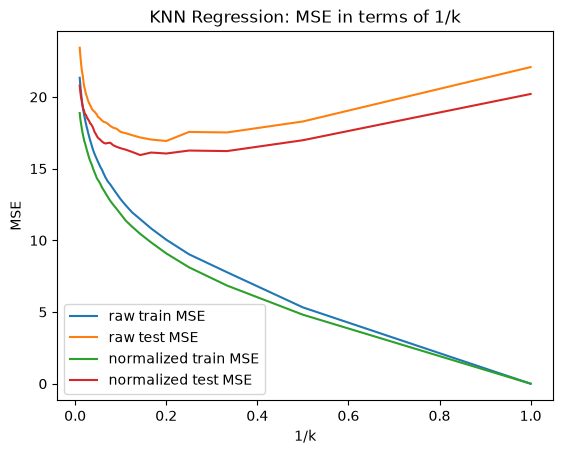

In [29]:
inverse_k = 1 / np.array(list(k_values))

plt.plot(
    inverse_k,
    mse_raw_train,
    label="raw train MSE"
)

plt.plot(
    inverse_k,
    mse_raw_test,
    label="raw test MSE"
)

plt.plot(
    inverse_k,
    mse_normalized_train,
    label="normalized train MSE"
)

plt.plot(
    inverse_k,
    mse_normalized_test,
    label="normalized test MSE"
)

plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression: MSE in terms of 1/k")
plt.legend()
plt.show()

### (j ) Compare KNN and Linear

Among the regression models, the selected model containing significant quadratic and interaction terms has the smallest test MSE of 20.0170. For KNN regression, the normalized features produce a minimum test MSE of 15.9485 at k=7. Therefore, KNN regression using normalized features has the best test performance. It suggests that KNN may capture local and nonlinear relationships that are not fully captured by the regression model.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

The performance of a flexible statistical learning method will be better.

The sample size n is extremely large, which satisfies the requirement that flexible methods generally need a large number of observations. In addition, a large n helps reduce the typically high variance of a flexible method and lowers the risk of overfitting. The number of predictors p is small, so the problem is not high-dimensional and the model can estimate complex relationships more reliably.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

The performance of a flexible statistical learning method will be worse than an inflexible method.

Since the number of observations n is small, a flexible method is likely to have high variance and may easily overfit beacuse of the limited training data. In addition, the extremely large number of predictors p makes the problem high-dimensional, which further increases the difficulty of estimating a flexible model reliably.

### (c) The relationship between the predictors and response is highly non-linear.

The performance of a flexible statistical learning method will be better when the relationship between the predictors and the response is highly nonlinear.

A flexible method can capture complex nonlinear patterns and therefore has lower bias. In contrast, an inflexible method may be unable to represent the true relationship and may suffer from high bias and underfitting.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

The performance of a flexible statistical learning method will be worse than an inflexible method when the variance of the error terms is extremely high.

A high variance of the error terms indicates that the data contain a large amount of irreducible noise. A flexible method may fit this noise and overfit the training data, resulting in high model variance. In contrast, an inflexible method has lower variance and is less likely to follow random noise.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [30]:
data_247 = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]
})

data_247["Distance"] = np.sqrt(
    (data_247[["X1", "X2", "X3"]] ** 2).sum(axis=1)
)

data_247.index = range(1, 7)
display(data_247)

,X1,X2,X3,Y,Distance
1,0,3,0,Red,3.000000
2,2,0,0,Red,2.000000
3,0,1,3,Red,3.162278
4,0,1,2,Green,2.236068
5,-1,0,1,Green,1.414214
6,1,1,1,Red,1.732051


### (b) What is our prediction with K = 1? Why?

In [31]:
nearest_1 = data_247.nsmallest(
    1,
    "Distance"
)

nearest_1

,X1,X2,X3,Y,Distance
5,-1,0,1,Green,1.414214


The prediction with K = 1 is Green because observation 5 has the smallest Euclidean distance, which means it is the closest training observation to the test point.

### (c) What is our prediction with K = 3? Why?

In [32]:
nearest_3 = data_247.nsmallest(
    3,
    "Distance"
)

nearest_3

,X1,X2,X3,Y,Distance
5,-1,0,1,Green,1.414214
6,1,1,1,Red,1.732051
2,2,0,0,Red,2.000000


The prediction with K = 3 is Red. When K = 3, the three nearest observations are observations 5, 6, and 2. Their responses are Green, Red, and Red. Since Red is the majority class, the prediction for K = 3 is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

As K increases, KNN becomes less flexible and its decision boundary becomes closer to linear. However, if the Bayes decision boundary is highly nonlinear, a more flexible KNN model is needed. Therefore, we would expect the best value for K to be relatively small.